In [4]:
# Use Google Colab secrets or a secure token prompt instead of hardcoding
from google.colab import userdata
try:
    TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    import getpass
    TOKEN = getpass.getpass('Enter your GitHub PAT: ')

REPO_URL = f"https://{TOKEN}@github.com/ValerioGomez/unmsm-research-methods-valeriogomez.git"

!git clone {REPO_URL}

%cd unmsm-research-methods-valeriogomez

Cloning into 'unmsm-research-methods-valeriogomez'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 113 (delta 10), reused 97 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 39.48 KiB | 2.47 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/unmsm-research-methods-valeriogomez/05_pipeline/unmsm-research-methods-valeriogomez


In [43]:
!git config --global user.email "valesitoo@gmail.com"
!git config --global user.name "Valerio Gomez"


In [10]:
# Navegar al directorio de trabajo y instalar dependencias
# El repositorio ya fue clonado en una celda anterior.
%cd /content/unmsm-research-methods-valeriogomez/05_pipeline
!pip install -r ../requirements.txt

/content/unmsm-research-methods-valeriogomez/05_pipeline


In [13]:
# Temporarily change directory to the repository root to inspect its contents
%cd /content/unmsm-research-methods-valeriogomez

# List all files and directories, including hidden ones, to check for .dvc folder
!ls -a

# Return to the original working directory
%cd /content/unmsm-research-methods-valeriogomez/05_pipeline

/content/unmsm-research-methods-valeriogomez
.	       05_pipeline     12_integrity	      .gitignore
..	       06_repro_audit  14_peer_review	      README.md
01_paradigm    07_model_card   admin_developer.ipynb  reflections
02_method      09_ethics       data		      requirements.txt
03_protocol    10_data_mgmt    Dockerfile
04_literature  11_bias_audit   .git
/content/unmsm-research-methods-valeriogomez/05_pipeline


In [16]:
# List the contents of the 'data' directory to check for 'churn_dataset.csv'
!ls -a /content/unmsm-research-methods-valeriogomez/data

.  ..  .gitkeep


In [14]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

import mlflow
import mlflow.sklearn

import warnings
warnings.filterwarnings('ignore')

# --- Fijar Semilla para asegurar Reproducibilidad ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Ajuste de estilo visual de los gráficos
sns.set_theme(style="whitegrid")
print('Reproducibility baseline established. SEED =', SEED)

Reproducibility baseline established. SEED = 42


In [34]:
# Cargar el dataset (ajusta la ruta según donde estés ejecutándolo en Colab)
# Si clonaste el repositorio en Colab, la ruta suele ser:
df = pd.read_csv('/content/unmsm-research-methods-valeriogomez/data/churn_dataset.csv', encoding='utf-16', sep=',')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 7)


,Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
0,1,56,0,275,2,3,0
1,2,69,0,381,8,1,0
2,3,46,1,219,5,2,0
3,4,32,1,58,2,2,0
4,5,60,1,89,4,4,0


In [28]:
# Resumen estadístico general de las variables cuantitativas
print("--- Summary Statistics ---")
print(df.describe())

# Verificación de datos faltantes (nulos)
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Summary Statistics ---
       Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
count                                                1000                                    
unique                                               1000                                    
top                                      1,56,0,275,2,3,0                                    
freq                                                    1                                    

--- Missing Values ---
Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn    0
dtype: int64


Overall Churn Rate: 24.20%


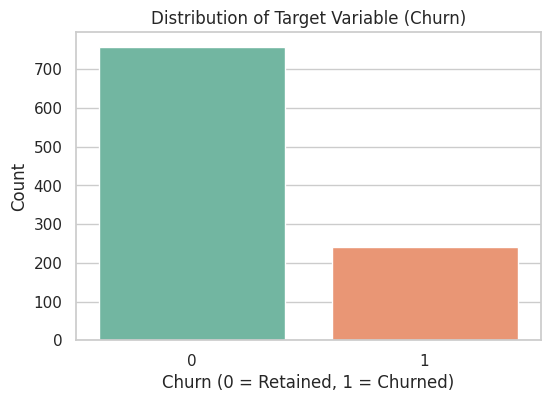

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Target Variable (Churn)')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Count')

# Mostrar proporción en consola
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
plt.show()

Overall Churn Rate: 24.20%


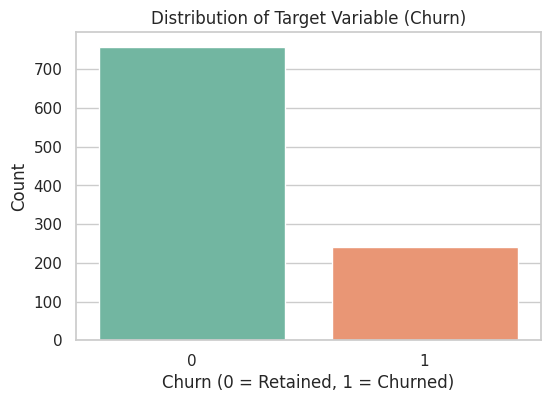

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Target Variable (Churn)')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Count')

# Mostrar proporción en consola
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
plt.show()

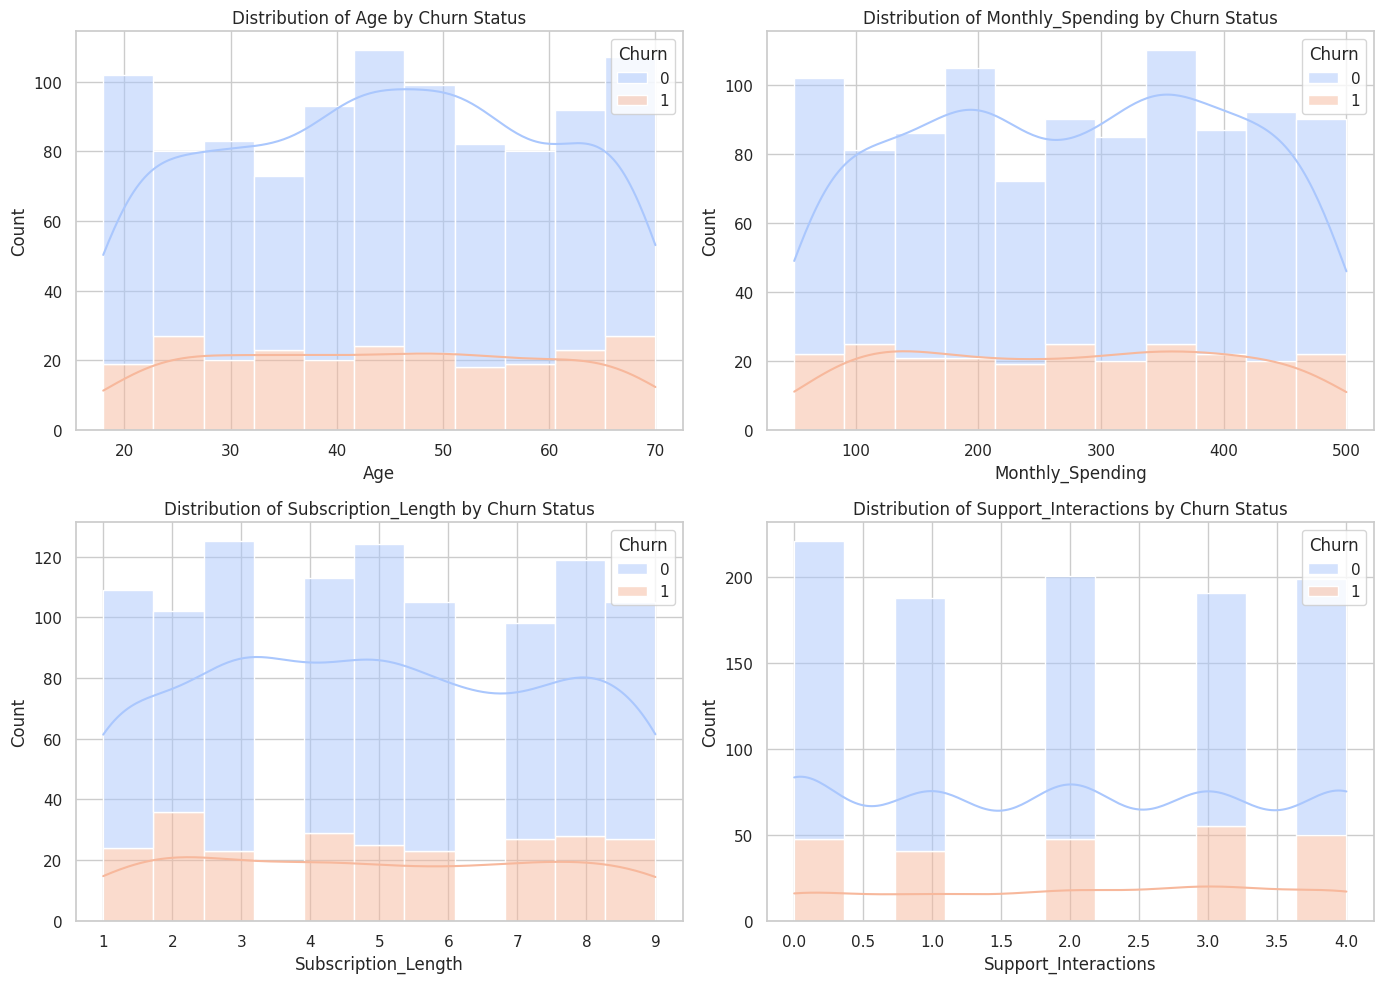

In [37]:
num_cols = ['Age', 'Monthly_Spending', 'Subscription_Length', 'Support_Interactions']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, palette='coolwarm', multiple='stack')
    ax.set_title(f'Distribution of {col} by Churn Status')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

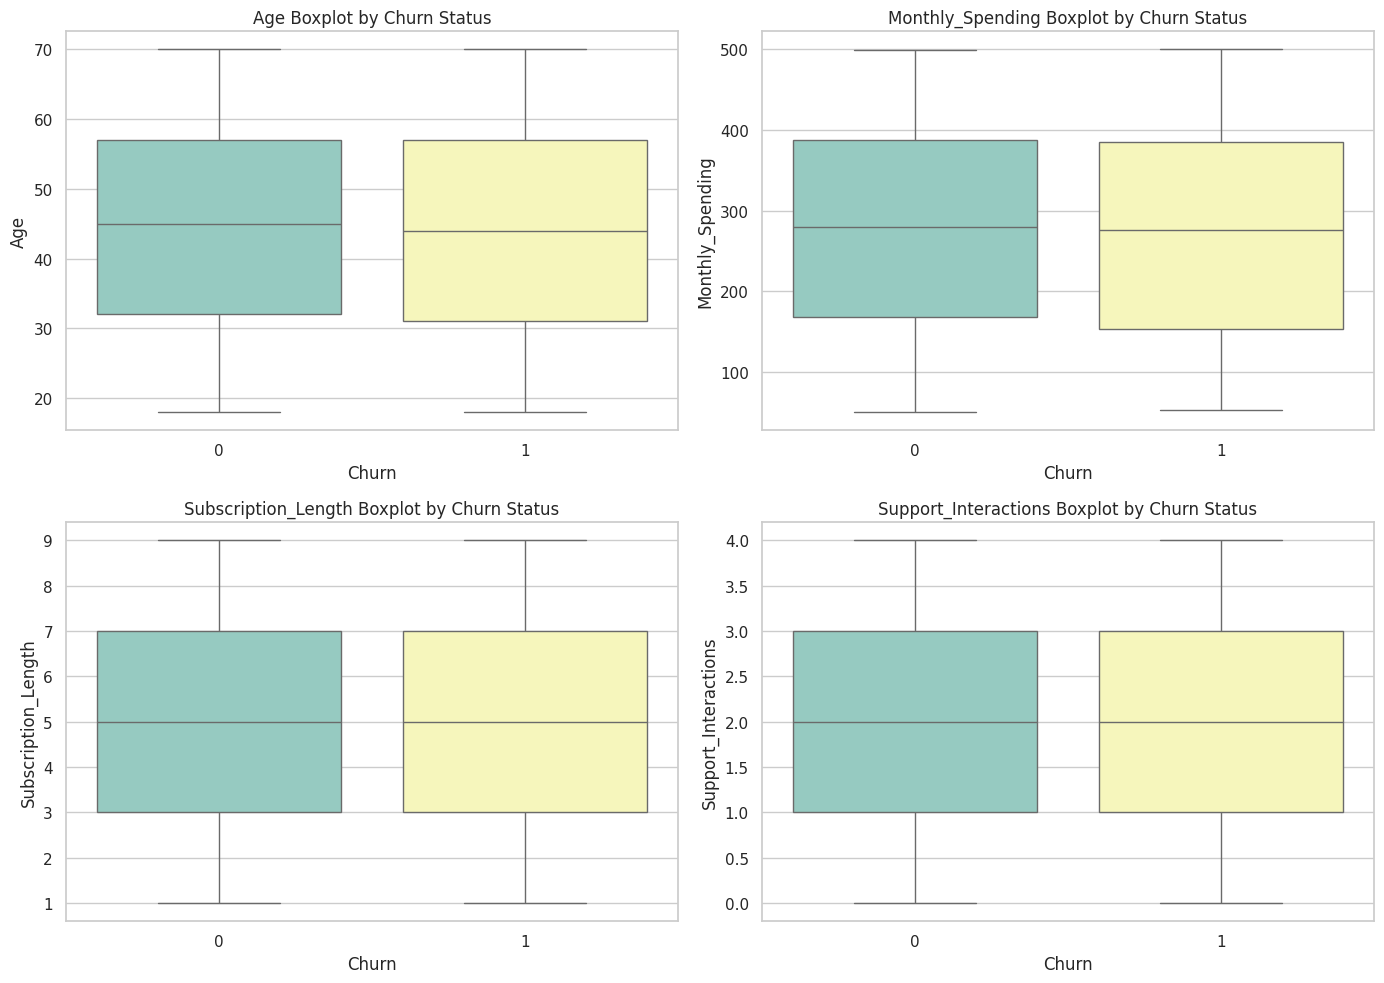

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, palette='Set3')
    ax.set_title(f'{col} Boxplot by Churn Status')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

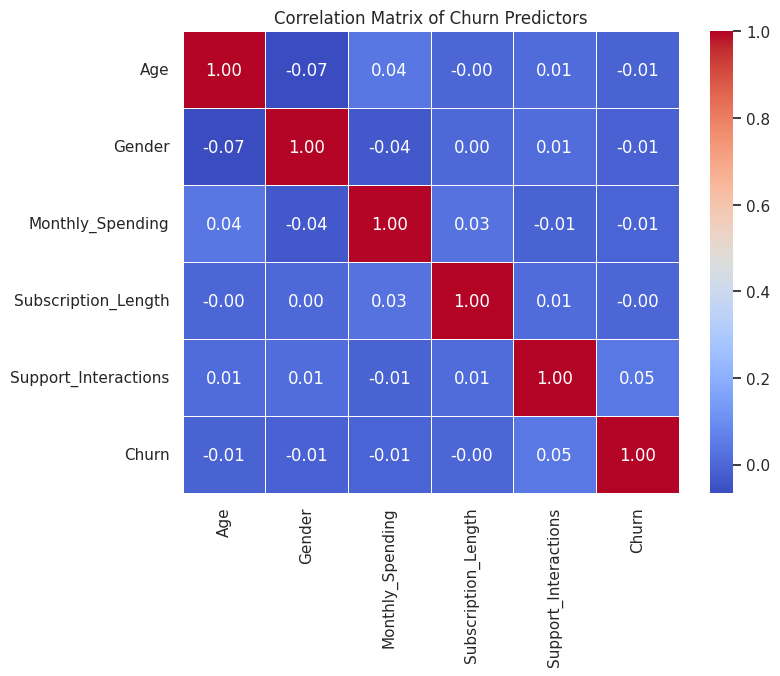

In [39]:
plt.figure(figsize=(8, 6))
# Excluimos Customer_ID porque no aporta valor numérico
corr_matrix = df.drop('Customer_ID', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Churn Predictors')
plt.show()

Sample counts by Gender:
Gender
0    524
1    476
Name: count, dtype: int64

Churn Rate by Gender:
   Gender  Churn_Rate
0       0    0.248092
1       1    0.235294


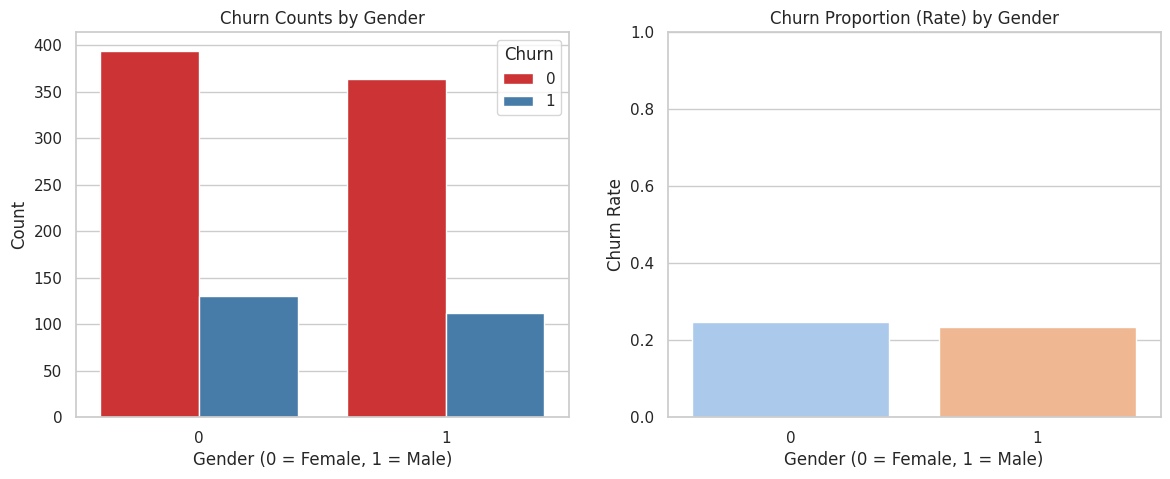

In [40]:
# Conteo por Género (0 = Femenino, 1 = Masculino)
print("Sample counts by Gender:")
print(df['Gender'].value_counts())

# Calcular el ratio de Churn por cada grupo de género
gender_churn = df.groupby('Gender')['Churn'].mean().reset_index()
gender_churn.columns = ['Gender', 'Churn_Rate']
print("\nChurn Rate by Gender:")
print(gender_churn)

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo absoluto
sns.countplot(x='Gender', hue='Churn', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Churn Counts by Gender')
axes[0].set_xlabel('Gender (0 = Female, 1 = Male)')
axes[0].set_ylabel('Count')

# Tasa de Churn (Proporción)
sns.barplot(x='Gender', y='Churn_Rate', data=gender_churn, ax=axes[1], palette='pastel')
axes[1].set_title('Churn Proportion (Rate) by Gender')
axes[1].set_xlabel('Gender (0 = Female, 1 = Male)')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 1.0)

plt.show()

In [41]:
# Dividir características y etiqueta
X = df.drop(['Customer_ID', 'Churn'], axis=1)
y = df['Churn']

# Split estratificado con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Escalar utilizando únicamente los parámetros del set de entrenamiento para evitar fuga de datos (data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (800, 5), Test size: (200, 5)


In [42]:
models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(random_state=SEED)
}

mlflow.set_experiment('Churn_Experiment')

results = []
for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)  # Sensibilidad (Recall)
        f1  = f1_score(y_test, y_pred)

        # Logear parámetros y métricas en MLflow
        mlflow.log_param('model', name)
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('recall', rec)
        mlflow.log_metric('f1', f1)
        mlflow.sklearn.log_model(model, name.replace(' ', '_'))

        results.append({'Model': name, 'Accuracy': acc, 'Recall': rec, 'F1': f1})
        print(f'{name}: Acc={acc:.4f}, Recall={rec:.4f}, F1={f1:.4f}')

results_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
print('\n--- Ranked by Recall ---')
print(results_df)

2026/06/21 12:46:12 INFO mlflow.tracking.fluent: Experiment with name 'Churn_Experiment' does not exist. Creating a new experiment.


Logistic Regression: Acc=0.7600, Recall=0.0000, F1=0.0000
Decision Tree: Acc=0.6350, Recall=0.2083, F1=0.2151
Random Forest: Acc=0.7700, Recall=0.1458, F1=0.2333
Gradient Boosting: Acc=0.7450, Recall=0.0417, F1=0.0727
SVM: Acc=0.7600, Recall=0.0000, F1=0.0000

--- Ranked by Recall ---
                 Model  Accuracy    Recall        F1
1        Decision Tree     0.635  0.208333  0.215054
2        Random Forest     0.770  0.145833  0.233333
3    Gradient Boosting     0.745  0.041667  0.072727
0  Logistic Regression     0.760  0.000000  0.000000
4                  SVM     0.760  0.000000  0.000000


**AUXILIAR**

In [47]:
!git add .

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> 05_pipeline/unmsm-research-methods-valeriogomez
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached 05_pipeline/unmsm-research-methods-valeriogomez
hint: 
hint: See "git help submodule" for more information.


In [48]:
!git commit -m "Executed pipeline and logged experiments from Google Colab"


[main 7adc785] Executed pipeline and logged experiments from Google Colab
 1 file changed, 1 insertion(+)
 create mode 160000 05_pipeline/unmsm-research-methods-valeriogomez


In [50]:
# Fetch and merge remote changes to synchronize local repository
!git pull origin main

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.13 KiB | 1.06 MiB/s, done.
From https://github.com/ValerioGomez/unmsm-research-methods-valeriogomez
 * branch            main       -> FETCH_HEAD
   88c5fb8..448cd81  main       -> origin/main
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override t

In [ ]:
# Configure git to use rebase strategy for pulls to handle divergent branches
!git config --global pull.rebase true

# Attempt to pull again after configuring the rebase strategy
!git pull origin main

In [51]:
!git push origin main

To https://github.com/ValerioGomez/unmsm-research-methods-valeriogomez.git
 ! [rejected]        main -> main (non-fast-forward)
error: failed to push some refs to 'https://github.com/ValerioGomez/unmsm-research-methods-valeriogomez.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.
